<a href="https://colab.research.google.com/github/fabriciothiengo/REATORES/blob/main/PRF_multiplas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **SISTEMA DE REAÇÕES MÚLTIPLAS ENVOLVENDO 5 COMPONENTES**
___

Considere um sistema químico com cinco componentes:
A, B, C, D e E.

As reações químicas que ocorrem no sistema são:

Reação 1:
A + B → C

Reação 2:
C → D

Reação 3:
C + B → E

<br>

**LEIS DE VELOCIDADE**

Assumindo comportamento elementar, as velocidades das reações são:

$r_1$ = $k1$ * $C_A$ * $C_B$

$r_2$ = $k2$ * $C_C$

$r_3$ = $k3$ * $C_C$ * $C_B$

$k_1$ = 2 l/mol h,
$k_2$ = 3 $h^{-1}$,
$k_3$ = 2 l/mol h

<br>

**BALANÇOS MOLARES EM REATOR PFR**

Os balanços diferenciais são:

$dF_A/dV$ = -$r_1$

$dF_B/dV$ = -$r_1$ - $r_3$

$dF_C/dV$ = $r_1$ - $r_2$ - $r_3$

$dF_D/dV$ = $r_2$

$dF_E/dV$ = $r_3$

<br>

**CONDIÇÕES INICIAIS**

No instante inicial:

$$CA(0) = C_{A_0} = 1M\\
CB(0) = C_{B_0} = 1M\\
CC(0) = 0\\
CD(0) = 0\\
CE(0) = 0$$


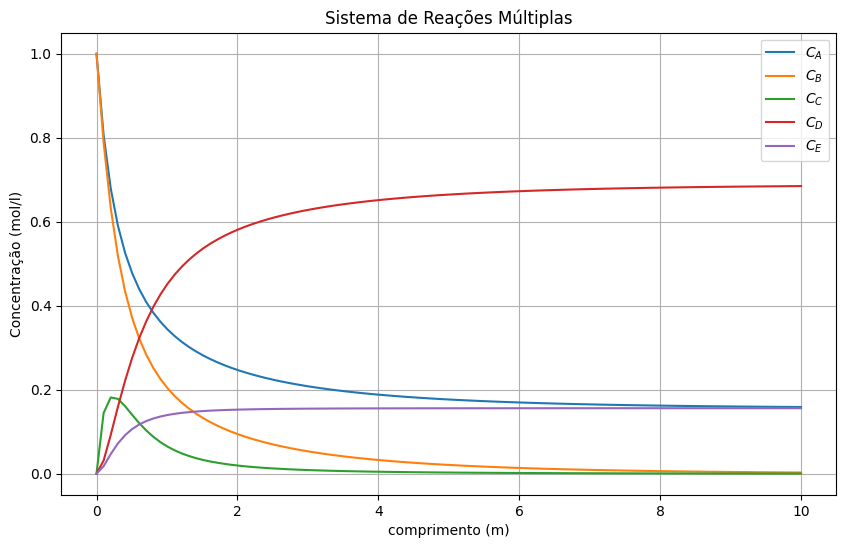

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# ============================================================
# SISTEMA DE REAÇÕES MÚLTIPLAS
#
# Reação 1: A + B -> C
# Reação 2: C -> D
# Reação 3: C + B -> E
# ============================================================

# -----------------------------
# Função do sistema de EDOs
# -----------------------------
def reacoes(t, y):

    # -----------------------------
    # Constantes cinéticas
    # -----------------------------
    k1 = 2.0
    k2 = 3.0
    k3 = 2.0
    A = 3
    v0 = 2.5

    # Variáveis de estado
    CA, CB, CC, CD, CE = y

    # Velocidades das reações
    r1 = k1 * CA * CB
    r2 = k2 * CC
    r3 = k3 * CC * CB

    # Equações diferenciais
    dCAdz = -(A/v0)*r1
    dCBdz = (A/v0)*(-r1 - r3)
    dCCdz = (A/v0)*(r1 - r2 - r3)
    dCDdz = (A/v0)*r2
    dCEdz = (A/v0)*r3

    return [dCAdz,dCBdz,dCCdz,dCDdz,dCEdz]

# -----------------------------
# Condições iniciais
# -----------------------------
CA0 = 1.0
CB0 = 1.0
CC0 = 0.0
CD0 = 0.0
CE0 = 0.0

y0 = [CA0,CB0,0,0,0]

# Pontos onde a solução será salva
z_eval = np.linspace(0, 10, 100)

# -----------------------------
# Solução numérica
# -----------------------------
sol = solve_ivp(reacoes, [z_eval[0], z_eval[-1]], y0, t_eval=z_eval, method='RK45')

# -----------------------------
# Extraindo resultados
# -----------------------------
z = sol.t

CA = sol.y[0]
CB = sol.y[1]
CC = sol.y[2]
CD = sol.y[3]
CE = sol.y[4]

# -----------------------------
# Gráficos
# -----------------------------
plt.figure(figsize=(10,6))

plt.plot(z, CA, label='$C_A$')
plt.plot(z, CB, label='$C_B$')
plt.plot(z, CC, label='$C_C$')
plt.plot(z, CD, label='$C_D$')
plt.plot(z, CE, label='$C_E$')

plt.xlabel('comprimento (m)')
plt.ylabel('Concentração (mol/l)')
plt.title('Sistema de Reações Múltiplas')
plt.legend()
plt.grid(True)
plt.show()